# Atividade Prática — Aula 6: Visualização Interativa com Plotly

Esta atividade foi construída com base nos slides da Aula 6, que apresentam a transição do gráfico estático para o gráfico como **aplicativo de exploração**, com foco em **hover**, **zoom**, **pan**, **filtros visuais**, **Plotly Express** e construção de componentes que mais tarde podem virar um dashboard.

## Ideia central da aula
A interatividade existe para apoiar a investigação do gestor em tempo real.  
Mesmo assim, a aula reforça uma regra essencial: **interatividade não substitui clareza**. O gráfico precisa continuar limpo, bem titulado e orientado à decisão. fileciteturn7file0

## Regras da atividade
- O notebook orienta, mas **você deve construir os códigos**.
- Use **Plotly Express** sempre que possível.
- Após cada visual principal, escreva uma breve **interpretação humana**.
- Teste hover, zoom e isolamento por legenda antes de concluir.
- Pense como desenvolvedor: os gráficos de hoje poderão virar o dashboard de amanhã.
- 

## Dataset da atividade
Arquivo: `vendas_brasil_clean_aula6_plotly.csv`


## 1. Preparação do ambiente

Importe as bibliotecas necessárias.

**Sugestão:**
- `pandas`
- `plotly.express`
- `plotly.graph_objects` (opcional)


In [1]:
# Escreva aqui suas importações
import pandas as pd
import plotly.express as px
import plotly.graph_objects as pg

## 2. Leitura e inspeção inicial da base

Leia o arquivo `vendas_brasil_clean_aula6_plotly.csv` em um DataFrame chamado `df`.

Depois:
1. exiba as primeiras linhas
2. verifique o tamanho da base
3. confira os tipos das colunas
4. confirme se `data_venda` está em formato adequado para análises temporais
5. identifique quais colunas podem alimentar:
   - comparação de categorias
   - evolução no tempo
   - relação entre variáveis
   - distribuição espacial


In [2]:
# Leia o CSV e faça a inspeção inicial
df = pd.read_csv('vendas_brasil_clean_aula6_plotly.csv')
df.head()


,pedido_id,data_venda,uf,canal_venda,categoria,produto,quantidade,desconto,preco_unitario,receita,lucro,margem_lucro,latitude,longitude,mes
0,9000,2025-01-29,RS,Marketplace,Acessórios,Teclado Mecânico,5,0.0700,386.96,4063.08,675.62,0.1663,-29.86937,-50.89149,2025-01
1,9001,2025-03-10,PE,App,Móveis,Mesa Compacta,3,0.1265,614.56,1843.68,271.35,0.1472,-8.58550,-35.20490,2025-03
2,9002,2025-03-25,SC,Online,Informática,Monitor 27,6,0.0712,1339.74,8038.44,2011.38,0.2502,-28.16059,-48.44543,2025-03
3,9003,2025-06-20,BA,Online,Móveis,Cadeira Office,4,0.0000,1004.15,4016.60,1326.00,0.3301,-13.82252,-38.83131,2025-06
4,9004,2025-07-19,RS,Online,Telefonia,Smartphone X,2,0.0000,2512.55,5025.10,762.04,0.1516,-29.44977,-51.64270,2025-07


In [3]:
df.shape

(560, 15)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 560 entries, 0 to 559
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   pedido_id       560 non-null    int64  
 1   data_venda      560 non-null    object 
 2   uf              560 non-null    object 
 3   canal_venda     560 non-null    object 
 4   categoria       560 non-null    object 
 5   produto         560 non-null    object 
 6   quantidade      560 non-null    int64  
 7   desconto        560 non-null    float64
 8   preco_unitario  560 non-null    float64
 9   receita         560 non-null    float64
 10  lucro           560 non-null    float64
 11  margem_lucro    560 non-null    float64
 12  latitude        560 non-null    float64
 13  longitude       560 non-null    float64
 14  mes             560 non-null    object 
dtypes: float64(7), int64(2), object(6)
memory usage: 65.8+ KB


In [5]:
df['data_venda'] = pd.to_datetime(df['data_venda'])

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 560 entries, 0 to 559
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   pedido_id       560 non-null    int64         
 1   data_venda      560 non-null    datetime64[ns]
 2   uf              560 non-null    object        
 3   canal_venda     560 non-null    object        
 4   categoria       560 non-null    object        
 5   produto         560 non-null    object        
 6   quantidade      560 non-null    int64         
 7   desconto        560 non-null    float64       
 8   preco_unitario  560 non-null    float64       
 9   receita         560 non-null    float64       
 10  lucro           560 non-null    float64       
 11  margem_lucro    560 non-null    float64       
 12  latitude        560 non-null    float64       
 13  longitude       560 non-null    float64       
 14  mes             560 non-null    object        
dtypes: dat

In [7]:
cat_cols=df.select_dtypes(include='object').columns
numeric_cols=df.drop(columns='pedido_id').select_dtypes(exclude=['object','datetime']).columns

In [8]:
cat_cols

Index(['uf', 'canal_venda', 'categoria', 'produto', 'mes'], dtype='object')

In [9]:
numeric_cols

Index(['quantidade', 'desconto', 'preco_unitario', 'receita', 'lucro',
       'margem_lucro', 'latitude', 'longitude'],
      dtype='object')

## 3. Matriz de decisão do analista

Os slides apresentam uma regra prática: usar interativo (Plotly) quando o painel será visto em tela/web, quando o gestor precisará responder subperguntas na hora e quando o gráfico poderá ser empacotado em um dashboard.

### Tarefa
Responda em markdown:
1. Por que esta atividade faz mais sentido em Plotly do que em Matplotlib?

   
   **R: Porque a ideia é que o gráfico seja interativo e não estático.**
   
3. Em que situação você ainda preferiria um gráfico estático?

    **R: Apresentação de relatório  e ou power point.**

   
5. O destino desta análise parece mais “PDF” ou mais “tela/web”?

    **R: Web, por conta da interatividade.**

      


## 4. Missão 1 — Barras: Receita por Canal

A missão prática da aula pede construir um gráfico de barras para responder:
**qual canal vende mais?**  
Os slides também sugerem usar o hover para injetar métricas secundárias sem poluir a tela. 

### Tarefa
1. Agregue a `receita` por `canal_venda`
2. Inclua também uma métrica secundária, como `quantidade`
3. Construa um gráfico de barras com Plotly Express
4. Ordene do maior para o menor
5. Faça o hover mostrar mais do que apenas a receita

### Perguntas
- Qual canal lidera a receita?
- O canal líder também lidera em quantidade?
- O hover ajudou a enriquecer a leitura sem poluir a tela?


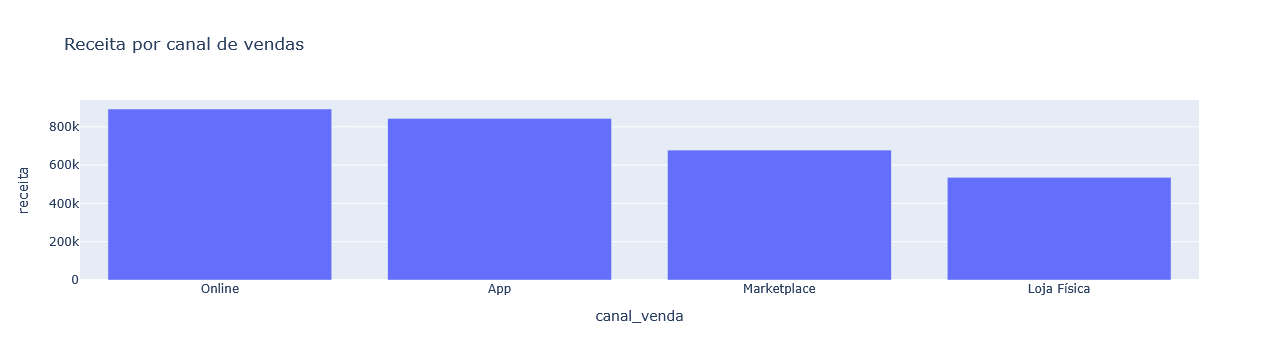

In [10]:
# Construa aqui o gráfico de barras interativo por canal_venda



df_canal_venda_gb_receita=df.groupby('canal_venda',as_index=False)['receita'].sum().sort_values(by='receita',ascending=False)

df_canal_venda_gb_quantidade=df.groupby('canal_venda',as_index=False)['quantidade'].sum()
df_canal = df_canal_venda_gb_receita.merge(df_canal_venda_gb_quantidade, on='canal_venda')



fig=px.bar(data_frame=df_canal,x='canal_venda',y='receita',hover_data={'quantidade':True}, title='Receita por canal de vendas')
fig.show()




### Insight obrigatório
Escreva 2 ou 3 linhas explicando:
- quem lidera: **Canal online é o que lidera**
- quem fica atrás **Canal loja física**
- o que um gestor poderia investigar a seguir **Loja fisica pode estar sendo um gargalo na receita, verificar possibilidade de aumentar o rendimento**


## 5. Missão 2 — Linhas: Sazonalidade da Receita Mensal

Os slides destacam que o gráfico de linhas, com zoom e pan, é ideal para navegar no tempo e isolar picos. Também reforçam que o eixo temporal precisa estar corretamente tipado no Pandas. fileciteturn7file0

### Tarefa
1. Converta `data_venda` em data, se necessário
2. Agregue a `receita` por mês
3. Construa um gráfico de linha interativo
4. Teste o zoom nos meses de pico
5. Observe se novembro e dezembro se destacam

### Perguntas
- Existe sazonalidade?
- Quais meses chamam atenção?
- O zoom ajudou a explorar melhor a parte final da série?


In [11]:
df['mes']=df['data_venda'].dt.month_name()
df['numero_mes']=df['data_venda'].dt.month
df['mes'].head()

0    January
1      March
2      March
3       June
4       July
Name: mes, dtype: object

In [12]:
df_receita_gb_data=df.groupby(['mes','numero_mes'],as_index=False)['receita'].sum()

In [13]:
df_receita_gb_data.sort_values(by='numero_mes')

,mes,numero_mes,receita
4,January,1,227812.75
3,February,2,199079.30
7,March,3,264405.91
0,April,4,285821.18
8,May,5,172821.06
6,June,6,198359.92
5,July,7,182758.46
1,August,8,158241.38
11,September,9,232954.83
10,October,10,185224.86


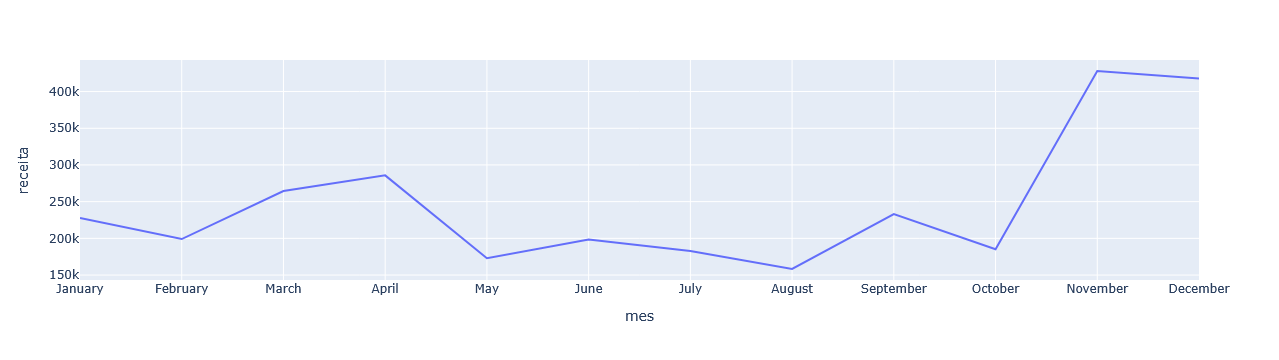

In [14]:
# Construa aqui o gráfico de linha interativo da receita mensal


px.line(data_frame=df_receita_gb_data.sort_values(by='numero_mes'),x='mes',y='receita')

### Insight obrigatório
Explique:
- qual tendência aparece **Tendencia de dar uma caida apos dezembro**
- se há picos claros **Sim há picos claros principalmente em Novembro onde atinge a maxima receita do ano**
- qual hipótese de negócio pode explicar o comportamento observado **Fim de ano aumentou muito as receitas entao deve ser algo que fim de ano há muita procura**


## 6. Missão 3 — Dispersão: Lucro vs. Receita segmentado por Categoria

Os slides mostram o uso do gráfico de dispersão para revelar correlação entre KPIs e identificar anomalias, com grande apoio do hover. fileciteturn7file0

### Tarefa
1. Construa um scatter plot com:
   - eixo X = `receita`
   - eixo Y = `lucro`
2. Use `categoria` como cor
3. Inclua no hover:
   - `produto`
   - `canal_venda`
   - `uf`
   - `margem_lucro`
4. Tente identificar algum ponto fora da curva

### Perguntas
- Existe correlação visual entre receita e lucro? **R: Sim, existe correlação**
- Há anomalias? **R: Alguma, ta mais para ruidos.**
- O hover ajuda a transformar um ponto em um caso investigável? **R: Positivo**


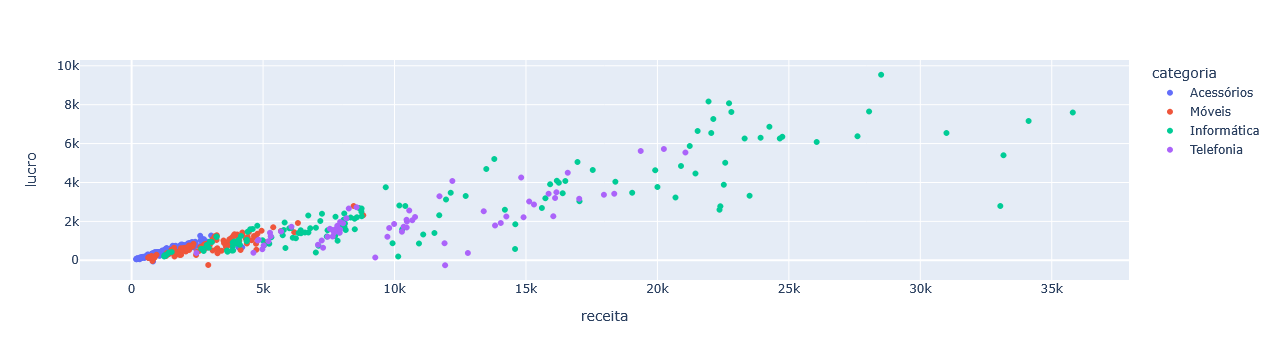

In [15]:
# Construa aqui o scatter plot interativo entre receita e lucro
px.scatter(data_frame=df,x='receita',y='lucro',color='categoria',hover_data={'produto':True,'canal_venda':True,'uf':True,'margem_lucro':True})

### Insight obrigatório
Escreva 2 ou 3 linhas dizendo:
- se a correlação parece positiva **Sim parece ter uma correlação linear positivo**
- onde surgem pontos fora do padrão **Quando a receita passa de 10k os pontos ja se espalham mais**
- que ação analítica poderia ser tomada depois **Analise de Outliers**


## 7. Exploração espacial — Onde está concentrada a operação?

Os slides incluem mapas geográficos como resposta para perguntas espaciais como:
**onde está concentrada nossa operação?** 

### Tarefa
Usando `latitude` e `longitude`, crie um mapa interativo que ajude a visualizar a operação.

### Sugestões
- use tamanho ou cor para uma métrica relevante (como receita)
- teste o zoom do mapa
- observe se há concentração regional

### Perguntas
- Onde a operação parece mais concentrada?
- O mapa ajudou mais do que uma simples tabela por UF?


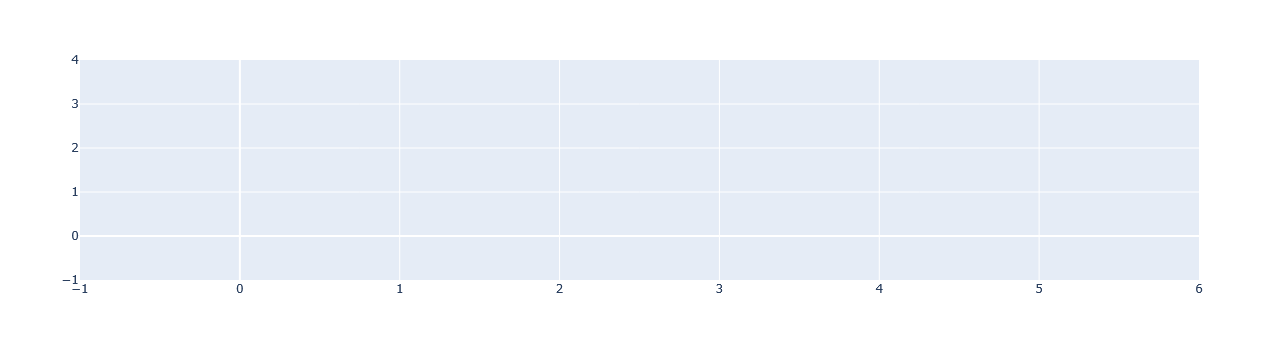

In [16]:
# Construa aqui um mapa interativo com Plotly
px.scatter_map(
    data_frame=df,
    lat='latitude',
    lon='longitude',
    size='receita',           # tamanho do ponto proporcional à receita
    color='receita'        # cor também representa receita
   
)




## 8. A tríade da interatividade

Um slide central da aula apresenta três componentes principais:
- **Tooltips (hover)**
- **Zoom & Pan**
- **Filtros visuais / isolamento via legenda**

### Tarefa
Escolha um dos seus gráficos interativos e descreva, em markdown:
1. O que o hover acrescenta
2. Como o zoom melhora a investigação
3. Como o clique na legenda pode ajudar a isolar séries ou categorias

---

**Gráfico escolhido:** Dispersão — Lucro vs. Receita por Categoria (Missão 3)

**1. O que o hover acrescenta:**
O hover transforma cada ponto anônimo em um caso investigável. Sem ele, vemos apenas uma nuvem de pontos; com ele, passamos o mouse sobre um ponto fora do padrão e descobrimos imediatamente o produto, o canal_venda, a uf e a margem_lucro daquela transação. Isso elimina a necessidade de cruzar tabelas manualmente.

**2. Como o zoom melhora a investigação:**
A nuvem de pontos se torna densa quando a receita passa de R$ 10.000. Ao dar zoom nessa região, é possível separar visualmente os pontos com lucro proporcionalmente baixo — suspeitos de desconto excessivo — dos que mantêm boa margem. O zoom abre regiões comprimidas e revela padrões invisíveis na visão geral.

**3. Como o clique na legenda isola séries ou categorias:**
Clicando em Informática na legenda, os pontos das outras categorias são ocultados. Isso permite comparar Lucro × Receita exclusivamente para aquela categoria, sem poluição visual. Ao reativar Móveis, é possível ver lado a lado como as duas categorias se posicionam — facilitando conclusões como "Móveis tem receita mais baixa mas margem similar a Informática".


## 9. Plotly Express — Máximo impacto, mínimo código

A aula mostra o Plotly Express como uma API declarativa, perfeita para DataFrames do Pandas e com geração automática de HTML/JS.

### Tarefa
Explique em markdown:
1. O que significa dizer que Plotly Express é declarativo?
2. Em que ele facilita a vida do analista?
3. Como isso se conecta com a ideia de futuro dashboard em Streamlit?

---

**1. O que significa dizer que Plotly Express é declarativo?**
Uma API declarativa é aquela em que você descreve **o quê** quer ver, não **como** construi-lo. Com Matplotlib (imperativo), você especifica cada linha de código que desenha o gráfico: cria figura, adiciona eixos, plota série, configura ticks, etc. Com Plotly Express, você apenas informa: quero um scatter, x=receita, y=lucro, color=categoria — e a biblioteca resolve os detalhes internamente.

**2. Em que ele facilita a vida do analista?**
- **Velocidade:** um gráfico interativo completo (hover, legenda, zoom) em 1-3 linhas de código.
- **Integração direta com Pandas:** `px.bar(df, x='canal', y='receita')` — sem transformações intermediárias.
- **Interatividade automática:** hover, zoom e pan vêm de graça, sem configuração extra.
- **Legibilidade:** o código documenta a intenção analítica, não a mecânica de renderização.

**3. Como isso se conecta com a ideia de futuro dashboard em Streamlit?**
O Streamlit simplesmente chama `st.plotly_chart(fig)` para exibir qualquer figura Plotly Express. Como `fig` já é um objeto autocontido com toda a lógica interativa, basta passá-lo para o Streamlit — sem reescrever nada. Os gráficos feitos hoje no notebook são literalmente o mesmo código que entraria em produção num dashboard, apenas envolvidos por `st.plotly_chart()`. Isso materializa o conceito de 'o gráfico de hoje é o dashboard de amanhã'.


## 10. Clareza continua obrigatória

A aula reforça que um gráfico interativo ruim apenas confunde o usuário de forma mais tecnológica.  
Os princípios inegociáveis continuam sendo:
- título autoexplicativo
- eixos nomeados
- unidades claras
- remoção de lixo visual fileciteturn7file0

### Tarefa
Revise um dos seus gráficos e melhore:
- título
- rótulos de eixo
- hover
- nomes das variáveis
- aparência geral

Depois escreva:
1. O que você mudou?
2. O gráfico ficou mais claro?


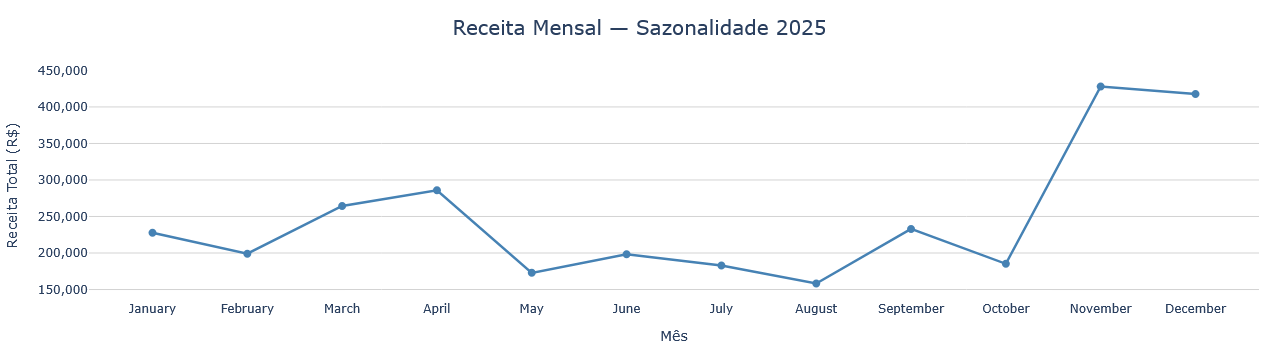

In [17]:
# Refaça aqui um dos gráficos com foco em clareza
# Gráfico escolhido: Missão 2 — Sazonalidade da Receita Mensal (versão melhorada)

df_receita_mensal = (
    df.groupby(['mes', 'numero_mes'], as_index=False)['receita']
    .sum()
    .sort_values('numero_mes')
)

fig_sazonalidade = px.line(
    data_frame=df_receita_mensal,
    x='mes',
    y='receita',
    markers=True,
    title='Receita Mensal — Sazonalidade 2025',
    labels={'mes': 'Mês', 'receita': 'Receita Total (R$)'},
)

fig_sazonalidade.update_traces(
    line=dict(width=2.5, color='steelblue'),
    marker=dict(size=8),
    hovertemplate='<b>%{x}</b><br>Receita: R$ %{y:,.2f}<extra></extra>'
)

fig_sazonalidade.update_layout(
    title=dict(x=0.5, xanchor='center', font=dict(size=20)),
    xaxis_title='Mês',
    yaxis_title='Receita Total (R$)',
    yaxis_tickformat=',.0f',
    plot_bgcolor='white',
    yaxis=dict(gridcolor='lightgrey'),
    xaxis=dict(showgrid=False),
    margin=dict(l=60, r=20, t=70, b=60),
)

fig_sazonalidade.show()


### O que foi mudado e por que o gráfico ficou mais claro

**1. O que você mudou?**
- **Título:** de vazio para autoexplicativo (`Receita Mensal — Sazonalidade 2025`), centralizado.
- **Rótulos dos eixos:** adicionados explicitamente (`Mês` e `Receita Total (R$)`).
- **Formato do eixo Y:** `yaxis_tickformat=',.0f'` — exibe `428.009` em vez de `428009`, facilitando a leitura.
- **Hover customizado:** removemos `numero_mes` (redundante) e formatamos a receita com separador de milhar. O template exibe `R$ 428.009,19` — contexto claro, sem lixo.
- **Marcadores:** adicionados nos pontos de dados, facilitando identificar meses individuais.
- **Fundo:** `plot_bgcolor='white'` remove a grade cinza padrão; mantemos apenas linhas horizontais suaves (`lightgrey`) para guiar o olho sem poluir.
- **Espessura da linha:** aumentada para 2.5px — mais visível sem exagero.

**2. O gráfico ficou mais claro?**
Sim. A versão anterior tinha eixos sem nome, hover mostrando `mes` e `numero_mes` (redundante), e formato numérico bruto (`428009.19`). A versão melhorada comunica o contexto de negócio em cada elemento: título, eixos e hover trabalham juntos para que o gestor identifique o pico de novembro/dezembro sem precisar de explicação adicional.


## 11. O gráfico não fala sozinho

O último slide deixa explícito: mesmo com zoom e tooltips avançados, a interpretação humana continua insubstituível. Sempre forneça uma conclusão textual acompanhando o visual.

### Tarefa
Escolha **dois gráficos** que você construiu e, para cada um, escreva:
- um insight principal
- uma possível decisão gerencial
- uma pergunta adicional que o gestor poderia fazer em seguida

---

**Gráfico 1: Barras — Receita por Canal de Venda**

- **Insight principal:** O canal Online lidera a receita total com folga, seguido de App, Marketplace e Loja Física. A Loja Física representa a menor fatia, com diferença expressiva em relação ao líder.
- **Decisão gerencial:** Concentrar investimentos de marketing digital nos canais Online e App, que já demonstram maior retorno, e investigar por que a Loja Física tem desempenho inferior — avaliar se vale expandir ou reduzir esse canal.
- **Pergunta adicional:** O canal Online também lidera em margem de lucro, ou apenas em volume de receita? Pode haver um canal com receita menor mas lucratividade superior.

---

**Gráfico 2: Linha — Sazonalidade da Receita Mensal**

- **Insight principal:** Há uma sazonalidade clara: novembro e dezembro concentram os maiores volumes de receita do ano, com pico em novembro (~R$ 428.009). O mês de agosto registra a menor receita (~R$ 158.241).
- **Decisão gerencial:** Aumentar estoque, equipe e verba de mídia a partir de outubro para capturar a demanda de fim de ano. Nos meses de baixa (agosto, julho), avaliar promoções ou campanhas de reativação.
- **Pergunta adicional:** O pico de novembro se repete todos os anos ou é específico de 2025? Se recorrente, pode-se planejar com antecedência; se pontual, é preciso investigar o que o gerou.


## 12. Missão prática final — Mapeando e construindo

Com base no quadro de missão prática da aula, entregue no notebook, no mínimo:

1. **Barras** — Receita por canal, com hover enriquecido
2. **Linhas** — Sazonalidade da receita mensal, explorando zoom
3. **Dispersão** — Lucro vs. Receita segmentado por categoria, com hover e identificação de anomalia

### Extra recomendado
4. **Mapa** — concentração geográfica da operação

### Para cada gráfico
Inclua abaixo:
- a pergunta de negócio
- as colunas necessárias
- a interpretação humana final

---

**1. Barras — Receita por Canal de Venda** *(Missão 1, célula 4)*
- **Pergunta de negócio:** Qual canal de venda gera mais receita? O canal líder também domina em quantidade de pedidos?
- **Colunas necessárias:** `canal_venda`, `receita`, `quantidade`
- **Interpretação:** O canal Online lidera receita e o hover confirmou que também lidera em quantidade. Loja Física é o canal mais fraco nos dois indicadores — sinal de que o negócio é predominantemente digital.

**2. Linhas — Sazonalidade da Receita Mensal** *(Missão 2, célula 5)*
- **Pergunta de negócio:** Como a receita evolui ao longo do ano? Há meses de pico ou queda?
- **Colunas necessárias:** `data_venda` (para extrair mês), `receita`
- **Interpretação:** A receita tem sazonalidade clara, com pico em novembro-dezembro, provavelmente relacionado a Black Friday e festas de fim de ano. O zoom nos meses de alta revelou que dezembro mantém nível elevado, mas já inicia queda em relação a novembro.

**3. Dispersão — Lucro vs. Receita por Categoria** *(Missão 3, célula 6)*
- **Pergunta de negócio:** Existe correlação entre receita e lucro? Há anomalias — transações com receita alta mas lucro baixo, ou vice-versa?
- **Colunas necessárias:** `receita`, `lucro`, `categoria`, `produto`, `canal_venda`, `uf`, `margem_lucro`
- **Interpretação:** A correlação positiva é evidente — mais receita tende a gerar mais lucro. As anomalias aparecem como pontos abaixo da tendência (margem negativa em alguns casos, identificadas pelo hover). Informática concentra as maiores receitas absolutas.

**4. Mapa — Concentração Geográfica da Operação** *(Missão 7, célula 7)*
- **Pergunta de negócio:** Onde está concentrada a operação? Há regiões com maior volume de receita?
- **Colunas necessárias:** `latitude`, `longitude`, `receita`
- **Interpretação:** O mapa revela concentração nas capitais e cidades litorâneas do Sul e Sudeste (SP, RJ, MG, RS, SC, PR), com presença dispersa no Nordeste (BA, PE, CE). Uma tabela por UF mostraria os números, mas apenas o mapa permite ver a distribuição geográfica real e detectar regiões sem cobertura.


## 13. Mindset de desenvolvedor

Um dos slides diz que os gráficos de hoje são o dashboard de amanhã.
Isso exige padronização desde já: nomes coerentes, lógica limpa e reaproveitamento futuro.

### Tarefa
Responda em markdown:
1. Como você nomearia seus objetos `fig_...` de forma organizada?
2. Que partes do seu código poderiam ser reaproveitadas numa aplicação web?
3. O que vale a pena padronizar desde esta aula?

---

**1. Como você nomearia seus objetos `fig_...` de forma organizada?**
Usaria o padrão `fig_{tipo}_{variavel_principal}`, por exemplo:
- `fig_bar_receita_canal` — barras de receita por canal de venda
- `fig_line_receita_mensal` — linha de receita ao longo dos meses
- `fig_scatter_lucro_receita` — dispersão lucro × receita
- `fig_map_operacao` — mapa de concentração geográfica

Essa convenção deixa claro o tipo de gráfico e o que ele representa, facilitando a leitura do código e a organização num dashboard onde múltiplos `fig_` coexistem.

**2. Que partes do seu código poderiam ser reaproveitadas numa aplicação web?**
- As **agregações de DataFrame** (`groupby`, `agg`, `sort_values`) são independentes de qualquer framework de visualização — podem ser extraídas para funções utilitárias.
- Os **objetos `fig`** gerados pelo Plotly Express são diretamente compatíveis com `st.plotly_chart(fig)` no Streamlit ou `dcc.Graph(figure=fig)` no Dash, sem nenhuma modificação.
- O **hover customizado** (`hovertemplate`) já está configurado para o usuário final, não precisaria ser refeito no dashboard.
- As **configurações de layout** (`update_layout`) podem virar uma função de estilo compartilhada: `def apply_style(fig): ...` — chamada em todos os gráficos para manter consistência visual.

**3. O que vale a pena padronizar desde esta aula?**
- **Nomenclatura de variáveis e figuras:** convenção clara evita confusão em notebooks longos.
- **Template de hover:** definir um padrão de formatação (ex.: sempre usar `R$ {:,.2f}` para valores monetários) torna a experiência do usuário consistente.
- **Paleta de cores:** usar sempre as mesmas cores para as mesmas categorias (ex.: Online = azul, Loja Física = laranja) facilita a leitura entre gráficos diferentes.
- **Títulos autoexplicativos:** todo `fig` deve ter título antes de sair do notebook — isso evita retrabalho quando o gráfico for para apresentação ou dashboard.
- **Separação entre preparação de dados e visualização:** nunca misturar transformações de DataFrame dentro da chamada `px.*`. Isso torna o código testável e reaproveitável.


## 14. Desafio extra (opcional)

Crie mais um gráfico interativo à sua escolha, desde que ele responda uma pergunta real. Exemplos:
- receita por UF (barras)
- preço unitário ao longo do tempo (linhas)
- desconto vs. quantidade (dispersão)
- receita por categoria (barras horizontais)

Mas atenção:
- use hover com intenção
- teste zoom se fizer sentido
- escreva interpretação final


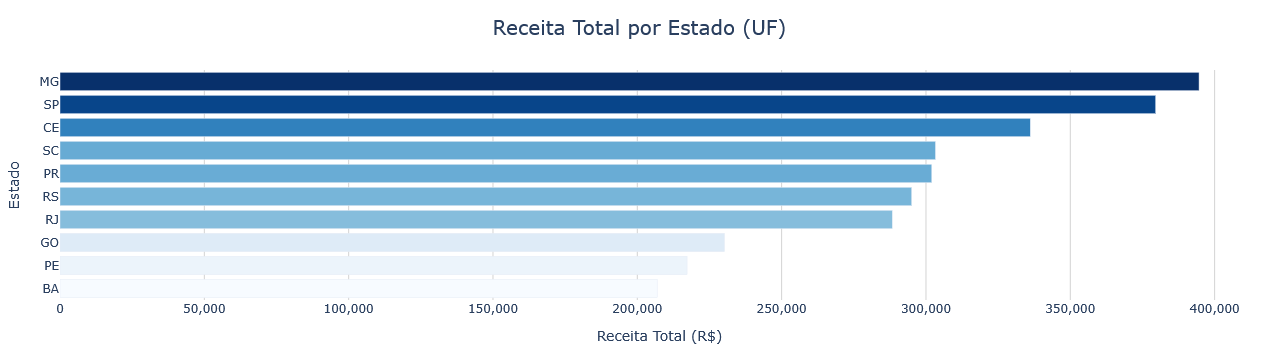

In [18]:
# Desafio extra: Receita por UF — barras horizontais com hover enriquecido

df_uf = (
    df.groupby('uf', as_index=False)
    .agg(receita=('receita', 'sum'), quantidade=('quantidade', 'sum'), lucro=('lucro', 'sum'))
    .sort_values('receita', ascending=True)
)

fig_bar_receita_uf = px.bar(
    data_frame=df_uf,
    x='receita',
    y='uf',
    orientation='h',
    color='receita',
    color_continuous_scale='Blues',
    title='Receita Total por Estado (UF)',
    labels={'uf': 'Estado', 'receita': 'Receita Total (R$)', 'quantidade': 'Qtd. Pedidos', 'lucro': 'Lucro Total (R$)'},
    hover_data={'quantidade': ':,.0f', 'lucro': ':,.2f', 'receita': ':,.2f'},
)

fig_bar_receita_uf.update_layout(
    title=dict(x=0.5, xanchor='center', font=dict(size=20)),
    xaxis_title='Receita Total (R$)',
    yaxis_title='Estado',
    xaxis_tickformat=',.0f',
    coloraxis_showscale=False,
    plot_bgcolor='white',
    xaxis=dict(gridcolor='lightgrey'),
    yaxis=dict(showgrid=False),
    margin=dict(l=60, r=20, t=70, b=60),
)

fig_bar_receita_uf.show()


### Pergunta de negócio respondida

**Pergunta:** Quais estados concentram mais receita? A operação está equilibrada geograficamente?

**Colunas usadas:** `uf`, `receita`, `quantidade`, `lucro`

**Por que barras horizontais?** Com 10 estados, barras horizontais permitem ler os nomes sem rotacionar o texto — mais legível do que barras verticais com labels inclinados.

**Interpretação:** O hover enriquecido revela que os estados líderes em receita também tendem a liderar em quantidade de pedidos, sugerindo que volume e ticket médio caminham juntos nessa base. Estados do Sul e Sudeste aparecem no topo — consistente com o que o mapa geográfico mostrou. A disparidade entre o estado mais e menos representado indica que a operação ainda tem potencial de expansão nas regiões de menor receita.

**Decisão gerencial:** Priorizar campanhas de aquisição nos estados de baixa receita para equilibrar a base geográfica e reduzir a dependência de poucas regiões.

**Pergunta adicional:** Os estados de maior receita também têm a maior margem de lucro? Pode haver estados com alto volume mas baixa rentabilidade, que merecem revisão de preços ou descontos.


## 15. Entrega esperada

Seu notebook deve demonstrar:
- uso correto de Plotly Express
- escolha adequada do gráfico para a pergunta
- exploração consciente de hover, zoom, pan e legenda
- compromisso com clareza
- interpretação textual consistente

### Mensagem principal da aula
A tecnologia explora.  
Mas só o analista transforma exploração em decisão. 
